
===== DATA LOADED SUCCESSFULLY =====

===== TOP 10 RUN SCORERS =====
             batter  total_runs  balls_faced  strike_rate
631         V Kohli        8014         6236   128.511867
512        S Dhawan        6769         5483   123.454313
477       RG Sharma        6630         5183   127.918194
147       DA Warner        6567         4849   135.429986
546        SK Raina        5536         4177   132.535312
374        MS Dhoni        5243         3947   132.835065
30   AB de Villiers        5181         3487   148.580442
124        CH Gayle        4997         3516   142.121729
501      RV Uthappa        4954         3927   126.152279
282      KD Karthik        4843         3687   131.353404

===== TOP 10 STRIKE RATES =====
              batter  total_runs  balls_faced  strike_rate
312           L Wood           9            3   300.000000
97        B Stanlake           5            2   250.000000
234  J Fraser-McGurk         330          150   220.000000
461    R Sai Kishore   

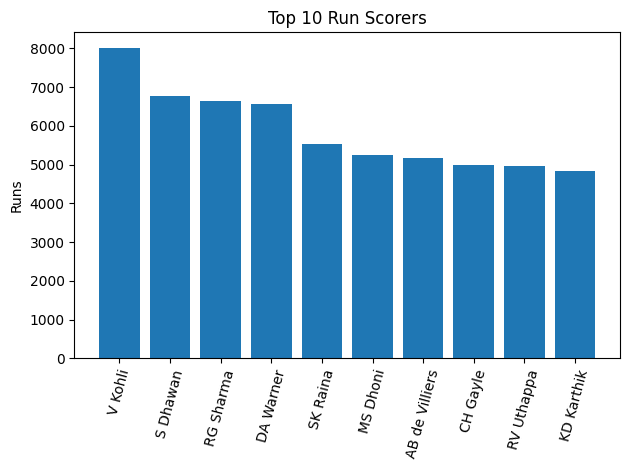

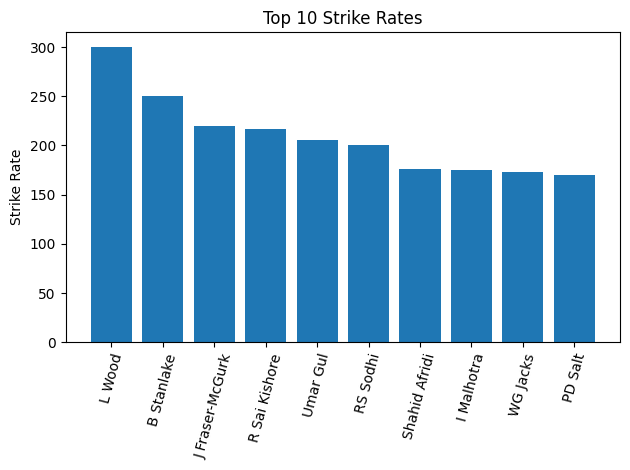

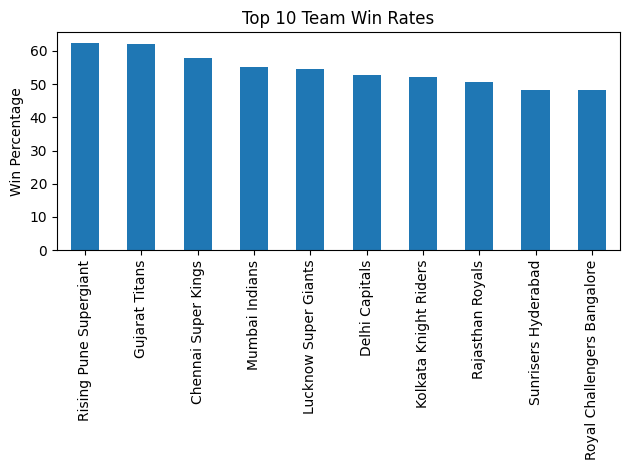

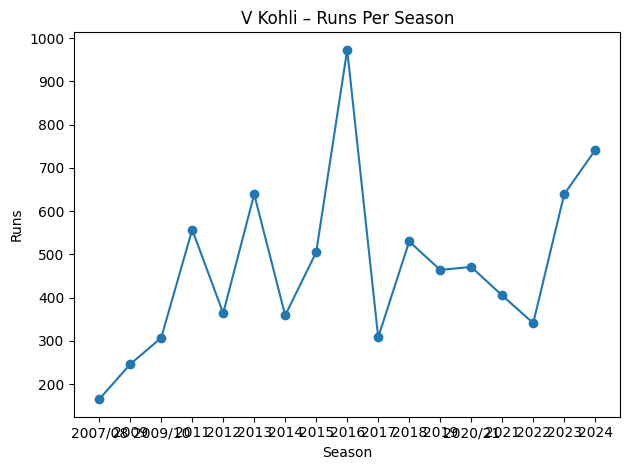

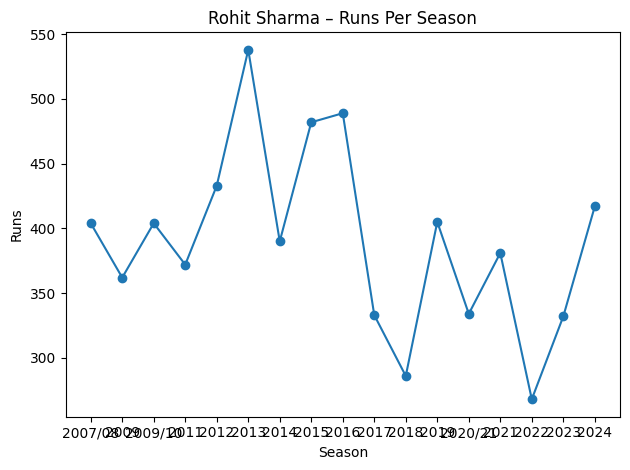


===== FINAL INSIGHTS SUMMARY =====
  Top Scorer  Top Scorer Runs Best Strike Rate Player  Strike Rate  \
0    V Kohli             8014                  L Wood        300.0   

     Best Team (Win Rate)  Win Rate %  Rohit Sharma Runs  \
0  Rising Pune Supergiant        62.5               6630   

   Rohit Sharma Strike Rate  
0                    127.92  

Analysis complete. File saved as visual_summary.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Load CSV files
# -------------------------------
deliveries = pd.read_csv("deliveries.csv")
matches = pd.read_csv("matches.csv")

print("\n===== DATA LOADED SUCCESSFULLY =====")

# =================================================
# 1. TOP SCORERS & STRIKE RATES
# =================================================
batting_stats = deliveries.groupby("batter").agg(
    total_runs=("batsman_runs", "sum"),
    balls_faced=("ball", "count")
).reset_index()

batting_stats["strike_rate"] = (batting_stats["total_runs"] /
                                batting_stats["balls_faced"]) * 100

top_scorers = batting_stats.sort_values(
    "total_runs", ascending=False).head(10)

top_strike_rates = batting_stats.sort_values(
    "strike_rate", ascending=False).head(10)

print("\n===== TOP 10 RUN SCORERS =====")
print(top_scorers)

print("\n===== TOP 10 STRIKE RATES =====")
print(top_strike_rates)

# =================================================
# 2. TEAM WIN RATES
# =================================================
team_wins = matches["winner"].value_counts()

team_matches = pd.concat([
    matches["team1"],
    matches["team2"]
]).value_counts()

team_win_rate = (team_wins / team_matches * 100).dropna()
team_win_rate = team_win_rate.sort_values(ascending=False)

print("\n===== TEAM WIN RATES (TOP 10) =====")
print(team_win_rate.head(10))

# =================================================
# 3. PER-SEASON PLAYER METRICS
# =================================================
season_data = deliveries.merge(
    matches[["id", "season"]],
    left_on="match_id",
    right_on="id"
)

season_player_runs = season_data.groupby(
    ["season", "batter"]
)["batsman_runs"].sum().reset_index()

print("\n===== SAMPLE PER-SEASON PLAYER RUNS =====")
print(season_player_runs.head(10))

# =================================================
# 4. PLAYER COMPARISON ACROSS SEASONS (TOP SCORER)
# =================================================
top_player = top_scorers.iloc[0]["batter"]

player_season_performance = season_player_runs[
    season_player_runs["batter"] == top_player
]

print(f"\n===== {top_player} PERFORMANCE ACROSS SEASONS =====")
print(player_season_performance)

# =================================================
# 5. ROHIT SHARMA PERFORMANCE (ADDED SECTION)
# =================================================
rohit_data = deliveries[deliveries["batter"] == "RG Sharma"]

rohit_total_runs = rohit_data["batsman_runs"].sum()
rohit_balls = rohit_data.shape[0]
rohit_strike_rate = (rohit_total_runs / rohit_balls) * 100

print("\n===== ROHIT SHARMA OVERALL PERFORMANCE =====")
print("Total Runs :", rohit_total_runs)
print("Balls Faced:", rohit_balls)
print("Strike Rate:", round(rohit_strike_rate, 2))

rohit_season = rohit_data.merge(
    matches[["id", "season"]],
    left_on="match_id",
    right_on="id"
)

rohit_season_runs = rohit_season.groupby(
    "season"
)["batsman_runs"].sum().reset_index()

print("\n===== ROHIT SHARMA SEASON-WISE RUNS =====")
print(rohit_season_runs)

# =================================================
# 6. VISUALIZATIONS
# =================================================

# Top Run Scorers
plt.figure()
plt.bar(top_scorers["batter"], top_scorers["total_runs"])
plt.xticks(rotation=75)
plt.title("Top 10 Run Scorers")
plt.ylabel("Runs")
plt.tight_layout()
plt.show()

# Top Strike Rates
plt.figure()
plt.bar(top_strike_rates["batter"], top_strike_rates["strike_rate"])
plt.xticks(rotation=75)
plt.title("Top 10 Strike Rates")
plt.ylabel("Strike Rate")
plt.tight_layout()
plt.show()

# Team Win Rates
plt.figure()
team_win_rate.head(10).plot(kind="bar")
plt.title("Top 10 Team Win Rates")
plt.ylabel("Win Percentage")
plt.tight_layout()
plt.show()

# Top Player Performance Across Seasons
plt.figure()
plt.plot(player_season_performance["season"],
         player_season_performance["batsman_runs"],
         marker="o")
plt.title(f"{top_player} – Runs Per Season")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.tight_layout()
plt.show()

# Rohit Sharma Performance Across Seasons
plt.figure()
plt.plot(rohit_season_runs["season"],
         rohit_season_runs["batsman_runs"],
         marker="o")
plt.title("Rohit Sharma – Runs Per Season")
plt.xlabel("Season")
plt.ylabel("Runs")
plt.tight_layout()
plt.show()

# =================================================
# 7. FINAL SUMMARY & EXPORT
# =================================================
summary = pd.DataFrame({
    "Top Scorer": [top_player],
    "Top Scorer Runs": [top_scorers.iloc[0]["total_runs"]],
    "Best Strike Rate Player": [top_strike_rates.iloc[0]["batter"]],
    "Strike Rate": [round(top_strike_rates.iloc[0]["strike_rate"], 2)],
    "Best Team (Win Rate)": [team_win_rate.index[0]],
    "Win Rate %": [round(team_win_rate.iloc[0], 2)],
    "Rohit Sharma Runs": [rohit_total_runs],
    "Rohit Sharma Strike Rate": [round(rohit_strike_rate, 2)]
})

summary.to_csv("visual_summary.csv", index=False)

print("\n===== FINAL INSIGHTS SUMMARY =====")
print(summary)

print("\nAnalysis complete. File saved as visual_summary.csv")